<a href="https://colab.research.google.com/github/sinakian/ai-lab-pumpkin-seeds/blob/pavel-rf-model/Pumpkin_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORT

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import seaborn as sns # library for making statistical and visualizations
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

# DATASET

In [ ]:
data = pd.read_excel('/content/drive/MyDrive/Pumpkin Project/Pumpkin_Seeds_Dataset.xlsx')


In [ ]:
data.shape

(2500, 13)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               2500 non-null   int64  
 1   Perimeter          2500 non-null   float64
 2   Major_Axis_Length  2500 non-null   float64
 3   Minor_Axis_Length  2500 non-null   float64
 4   Convex_Area        2500 non-null   int64  
 5   Equiv_Diameter     2500 non-null   float64
 6   Eccentricity       2500 non-null   float64
 7   Solidity           2500 non-null   float64
 8   Extent             2500 non-null   float64
 9   Roundness          2500 non-null   float64
 10  Aspect_Ration      2500 non-null   float64
 11  Compactness        2500 non-null   float64
 12  Class              2500 non-null   object 
dtypes: float64(10), int64(2), object(1)
memory usage: 254.0+ KB


In [ ]:
data.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness,Class
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,Çerçevelik
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487,Çerçevelik
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929,Çerçevelik
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624,Çerçevelik
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557,Çerçevelik


In [ ]:
data.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,80658.220800,1130.279015,456.601840,225.794921,81508.084400,319.334230,0.860879,0.989492,0.693205,0.791533,2.041702,0.704121
std,13664.510228,109.256418,56.235704,23.297245,13764.092788,26.891920,0.045167,0.003494,0.060914,0.055924,0.315997,0.053067
min,47939.000000,868.485000,320.844600,152.171800,48366.000000,247.058400,0.492100,0.918600,0.468000,0.554600,1.148700,0.560800
25%,70765.000000,1048.829750,414.957850,211.245925,71512.000000,300.167975,0.831700,0.988300,0.658900,0.751900,1.801050,0.663475
50%,79076.000000,1123.672000,449.496600,224.703100,79872.000000,317.305350,0.863700,0.990300,0.713050,0.797750,1.984200,0.707700
75%,89757.500000,1203.340500,492.737650,240.672875,90797.750000,338.057375,0.897025,0.991500,0.740225,0.834325,2.262075,0.743500
max,136574.000000,1559.450000,661.911300,305.818000,138384.000000,417.002900,0.948100,0.994400,0.829600,0.939600,3.144400,0.904900


In [ ]:
data.nunique() # counts the number of different values

,0
Area,2424
Perimeter,2490
Major_Axis_Length,2499
Minor_Axis_Length,2497
Convex_Area,2445
Equiv_Diameter,2424
Eccentricity,1295
Solidity,166
Extent,1392
Roundness,1480


In [ ]:
data.isnull().sum()

,0
Area,0
Perimeter,0
Major_Axis_Length,0
Minor_Axis_Length,0
Convex_Area,0
Equiv_Diameter,0
Eccentricity,0
Solidity,0
Extent,0
Roundness,0


# DATA Preparation and EDA

In [ ]:
X = data.drop(columns='Class')
y = data['Class']


In [ ]:
data['Class'].value_counts(normalize=True)

,proportion
Class,
Çerçevelik,0.52
Ürgüp Sivrisi,0.48


In [ ]:
# coding classes in numbers

encoder = LabelEncoder()
y = encoder.fit_transform(y) # revert 2 classes to 0/1
print(y)

[0 0 0 ... 1 1 1]


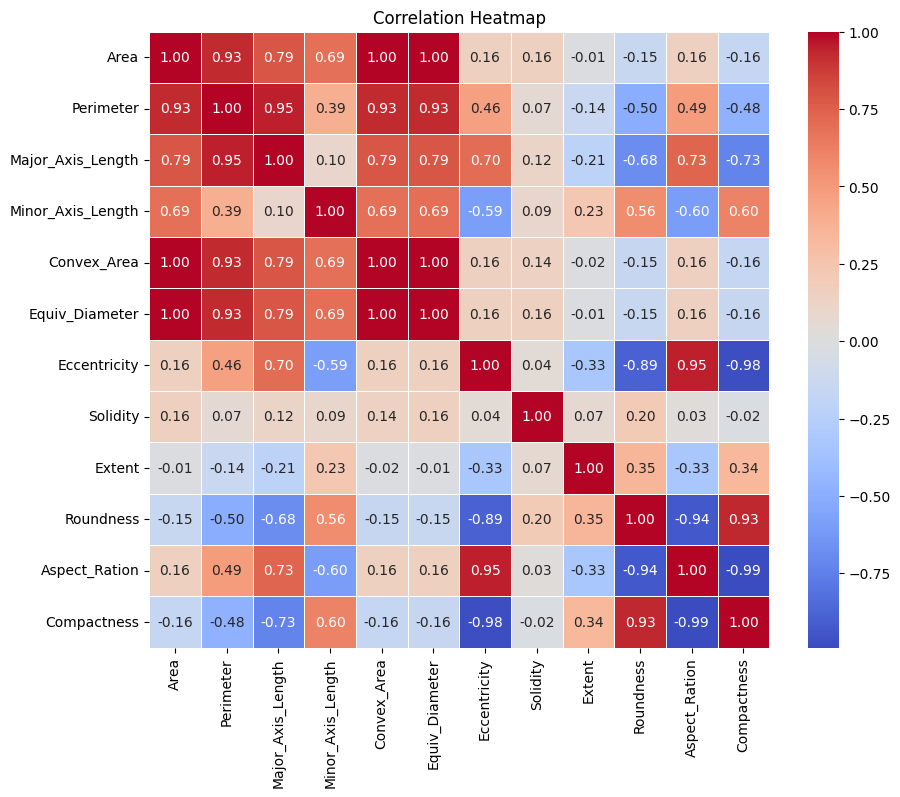

In [ ]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,      # show correlation values
    fmt=".2f",       # 2 decimal places
    cmap="coolwarm", # colors
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

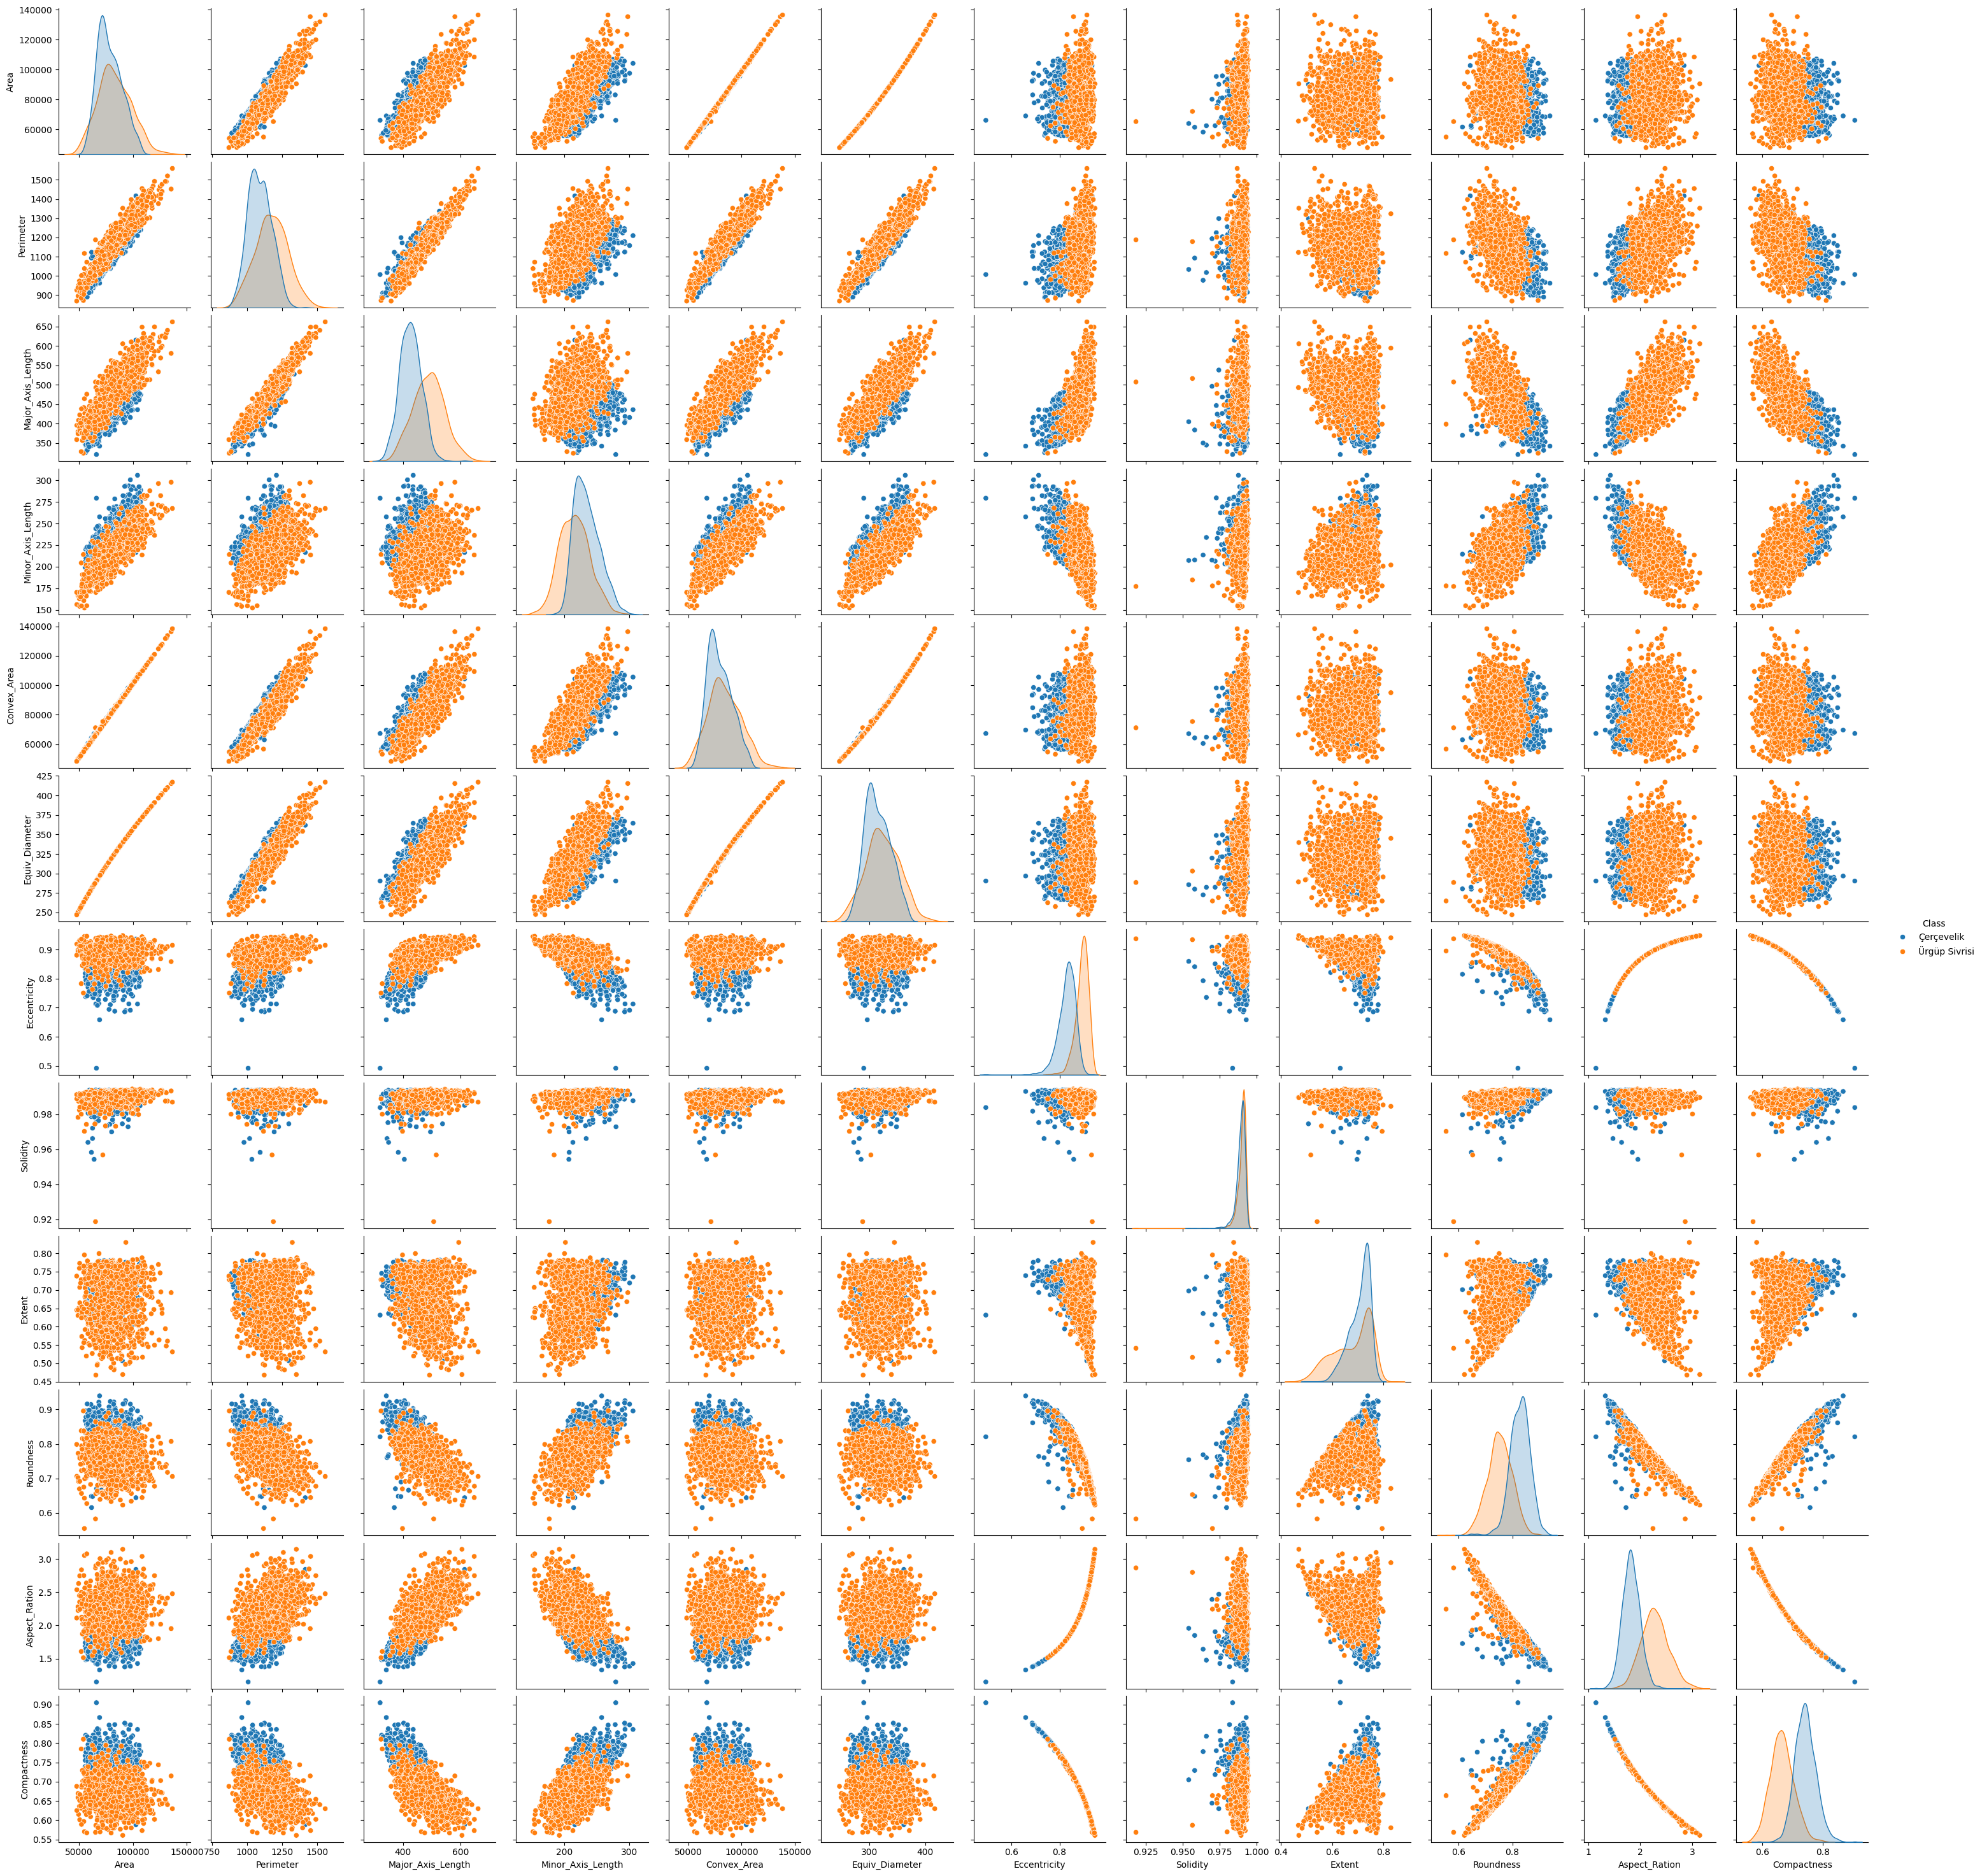

In [ ]:
sns.pairplot(data, hue="Class")
plt.show()

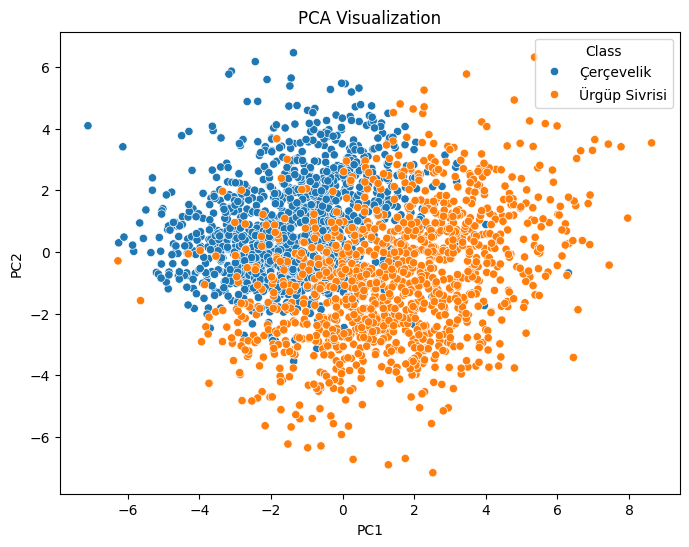

In [ ]:

x = data.drop('Class', axis=1) # axis=1 - find in columns(horisontal ), find 'class'
y = data['Class']

scaler = StandardScaler() # x_scaled​=(x − mean)​/std
x_scaled = scaler.fit_transform(x)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Class"] = y

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Class")
plt.title("PCA Visualization")
plt.show()


# TRAIN

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    y,
    random_state=42, # same split every run
    stratify=y # same class proportions
)

In [ ]:
rf = RandomForestClassifier(
    random_state=42
)

In [ ]:
# find best hyperparameters

parameters = {

    "n_estimators":[50,100,200,300],

    "max_depth":[3,5,10,None],

    "min_samples_split":[2,4,6],

    "min_samples_leaf":[1,2,4]

}

rf_search = RandomizedSearchCV(

    estimator=rf,

    param_distributions=parameters,

    n_iter=20,

    cv=5,

    scoring="accuracy",

    random_state=42

)

rf_search.fit(
    X_train,
    Y_train
)

rf_search.best_params_

{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 4,
 'max_depth': 10}

In [ ]:
best_rf = rf_search.best_estimator_

In [ ]:
Y_pred = best_rf .predict(X_test)

# EVALUATION

In [ ]:
accuracy = accuracy_score(
    Y_test,
    Y_pred
)

print(accuracy)

0.888


In [ ]:
cassif_report = classification_report(
    Y_test,
    Y_pred
)

print('Test_set', cassif_report)

Test_set               precision    recall  f1-score   support

           0       0.87      0.93      0.90       325
           1       0.91      0.85      0.88       300

    accuracy                           0.89       625
   macro avg       0.89      0.89      0.89       625
weighted avg       0.89      0.89      0.89       625



In [ ]:
conf_matrix = confusion_matrix(
    Y_test,
    Y_pred
)

print(conf_matrix) # [TN FP][FN TP]

[[301  24]
 [ 46 254]]


# VISUALIZATION